In [9]:
import os
import librosa
import scipy as sp
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
os.getcwd()


'/Users/siddharth'

In [12]:
# load audio file in the player

BASE_FOLDER = "Audio/AudioFiles/"
audio_path = os.path.join(BASE_FOLDER, "piano_c.wav")
ipd.Audio(audio_path)

In [11]:
# load audio file
signal, sr = librosa.load(audio_path)

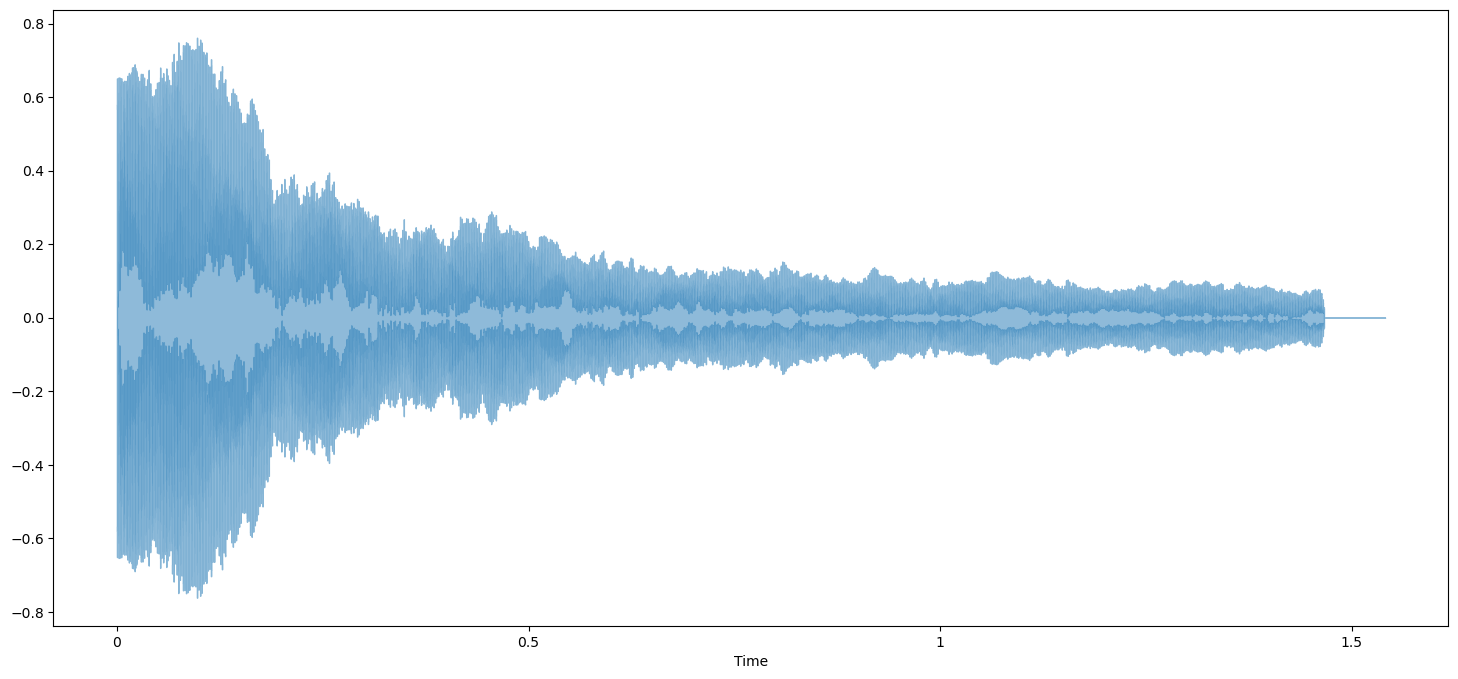

In [13]:
# plot waveform
plt.figure(figsize=(18, 8))
librosa.display.waveshow(signal, sr=sr, alpha=0.5)
plt.show()

In [25]:
# derive spectrum using FT
ft = sp.fft.fft(signal)
magnitude = np.absolute(ft)

frequency = np.linspace(0, sr, len(magnitude)) 
#len(magnitude) : 33968
#sr : 22050, It means your audio waveform has 22,050 samples per second.

In [26]:
N = len(signal)

ft = np.fft.fft(signal)
magnitude = np.abs(ft)

frequency = np.fft.fftfreq(N, d=1/sr)

positive_frequency = frequency[:N//2]
positive_magnitude = magnitude[:N//2]

In [ ]:
# np.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None)
start: The starting value of the sequence.stop: The end value of the sequence.num (Optional): Number of samples to generate. Default is 50.endpoint (Optional): If True (default), stop is included as the last value. If False, it is excluded.retstep (Optional): If True, returns a tuple containing the array and the calculated step size.dtype (Optional): The data type of the output array (e.g., int, float).

In [ ]:
sr = 22050
len(magnitude) = 33968

That means your FFT was computed on:

N = 33968

samples.

So this line:

frequency = np.linspace(0, sr, len(magnitude))

becomes:

frequency = np.linspace(0, 22050, 33968)

It creates 33,968 equally spaced frequency labels from:

0 Hz to 22050 Hz

So approximately:

frequency[0]     = 0 Hz
frequency[1]     ≈ 0.649 Hz
frequency[2]     ≈ 1.298 Hz
frequency[3]     ≈ 1.947 Hz
...
frequency[-1]    = 22050 Hz

The spacing is roughly: 22050/33968≈0.649 Hz

So your frequency resolution is about:

0.649 Hz per bin

Meaning each neighboring FFT bin is around 0.649 Hz apart.

Your audio duration is:

duration= N/sr


duration= 33968//22050 ≈1.54 seconds

So you loaded around:

1.54 seconds of audio

Since longer duration gives better frequency resolution:

Δf= sr/N

Δf= 22050/33968 ≈ 0.649 Hz

So the FFT can distinguish frequencies roughly every 0.649 Hz.

But again, this line:

frequency = np.linspace(0, sr, len(magnitude))

is not fully correct for FFT plotting.

For real audio, useful positive frequencies go only up to: sr/2 = 11025 Hz

So if you use full FFT:

ft = np.fft.fft(signal)
magnitude = np.abs(ft)

then you should usually plot only half:

N = len(signal)

frequency = np.fft.fftfreq(N, d=1/sr), d is spacing between two samples

positive_frequency = frequency[:N//2]
positive_magnitude = magnitude[:N//2]

For your values:

N//2 = 16984

So you would plot around:

16984 magnitude values

from:

0 Hz to almost 11025 Hz

Best version:

N = len(signal)

ft = np.fft.rfft(signal)
magnitude = np.abs(ft)

frequency = np.fft.rfftfreq(N, d=1/sr)

Here, since N = 33968, rfft will give:

N//2 + 1 = 16985 values

from:

0 Hz to 11025 Hz

So your key numbers are:

sr = 22050 samples/sec
N = 33968 samples
duration ≈ 1.54 sec
frequency resolution ≈ 0.649 Hz
Nyquist frequency = 11025 Hz
useful positive FFT bins = 16985 using rfft

In [34]:
N = len(signal) #33968
ft = np.fft.rfft(signal) #16985 as -ve values are discarded
magnitude = np.abs(ft)
frequency = np.fft.rfftfreq(N, d=1/sr)
"""
sr = 22050 samples/sec
N = 33968 samples
duration ≈ 1.54 sec
frequency resolution ≈ 0.649 Hz
Nyquist frequency = 11025 Hz
useful positive FFT bins = 16985 using rfft
"""

'\nsr = 22050 samples/sec\nN = 33968 samples\nduration ≈ 1.54 sec\nfrequency resolution ≈ 0.649 Hz\nNyquist frequency = 11025 Hz\nuseful positive FFT bins = 16985 using rfft\n'

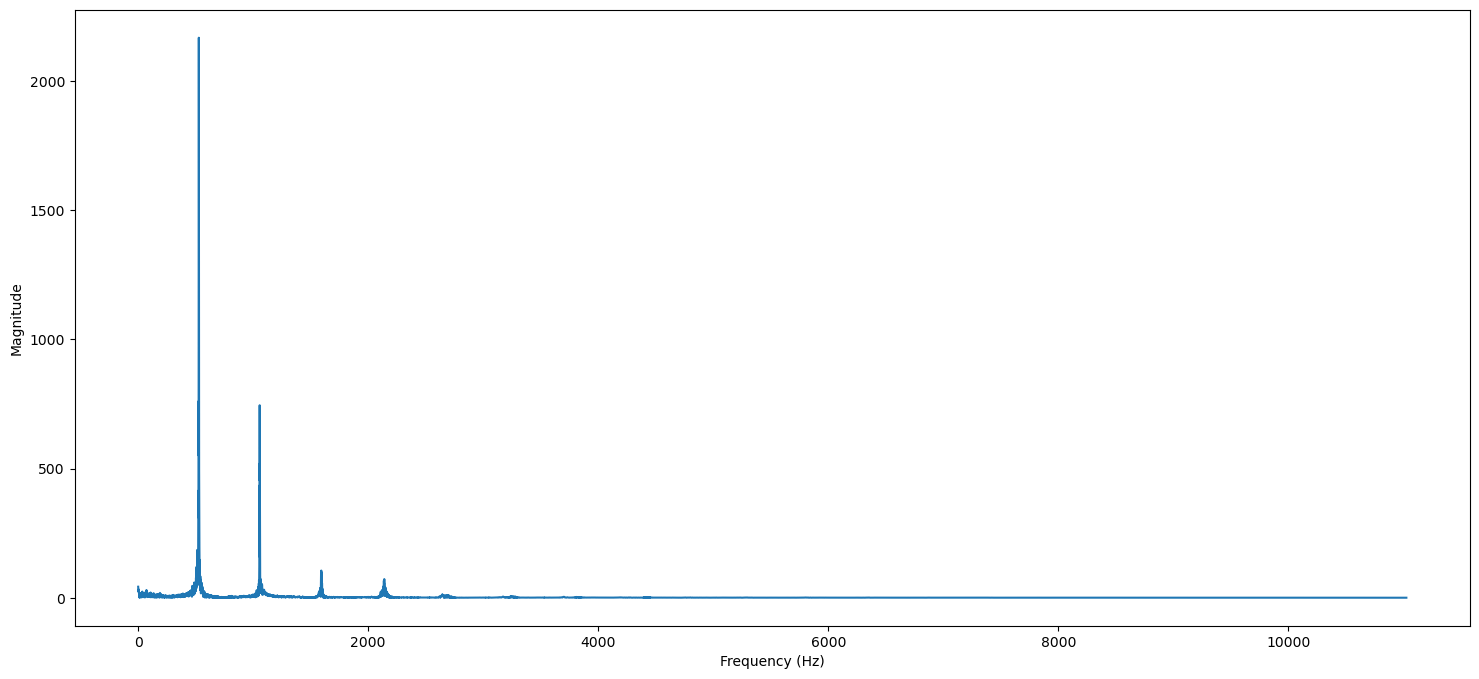

In [35]:
# plot spectrum
plt.figure(figsize=(18, 8))
plt.plot(frequency, magnitude) # magnitude spectrum
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [7]:
len(signal)

33968

In [8]:
d =  1 / sr
d

4.5351473922902495e-05

In [9]:
d_523 = 1 / 523
d_523

0.0019120458891013384

In [10]:
d_400_samples = 400 * d
d_400_samples

0.018140589569160998

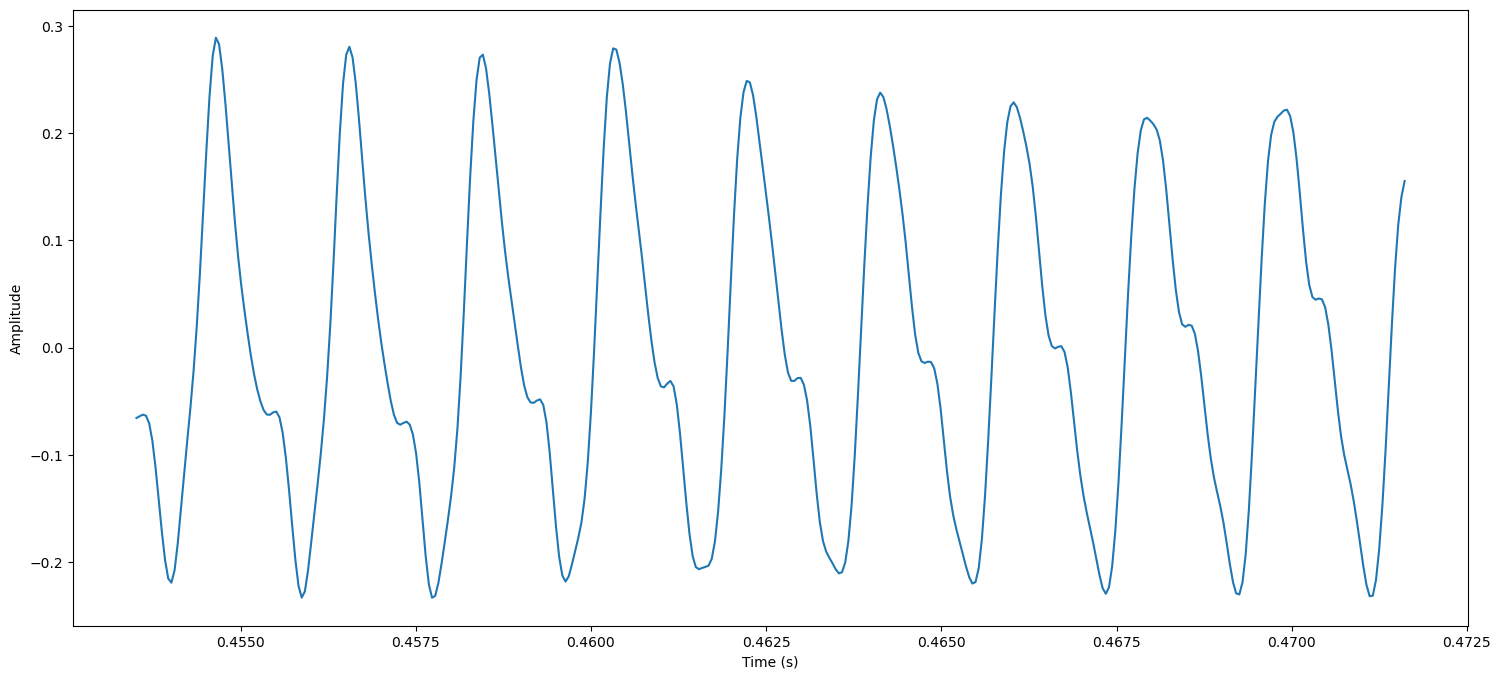

In [36]:
# zomm in to the waveform
samples = range(len(signal))
t = librosa.samples_to_time(samples, sr=sr)

plt.figure(figsize=(18, 8))
plt.plot(t[10000:10400], signal[10000:10400]) 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
#we are zooming into a portion of signal samples to time takes sample_value/sr which gives time duration

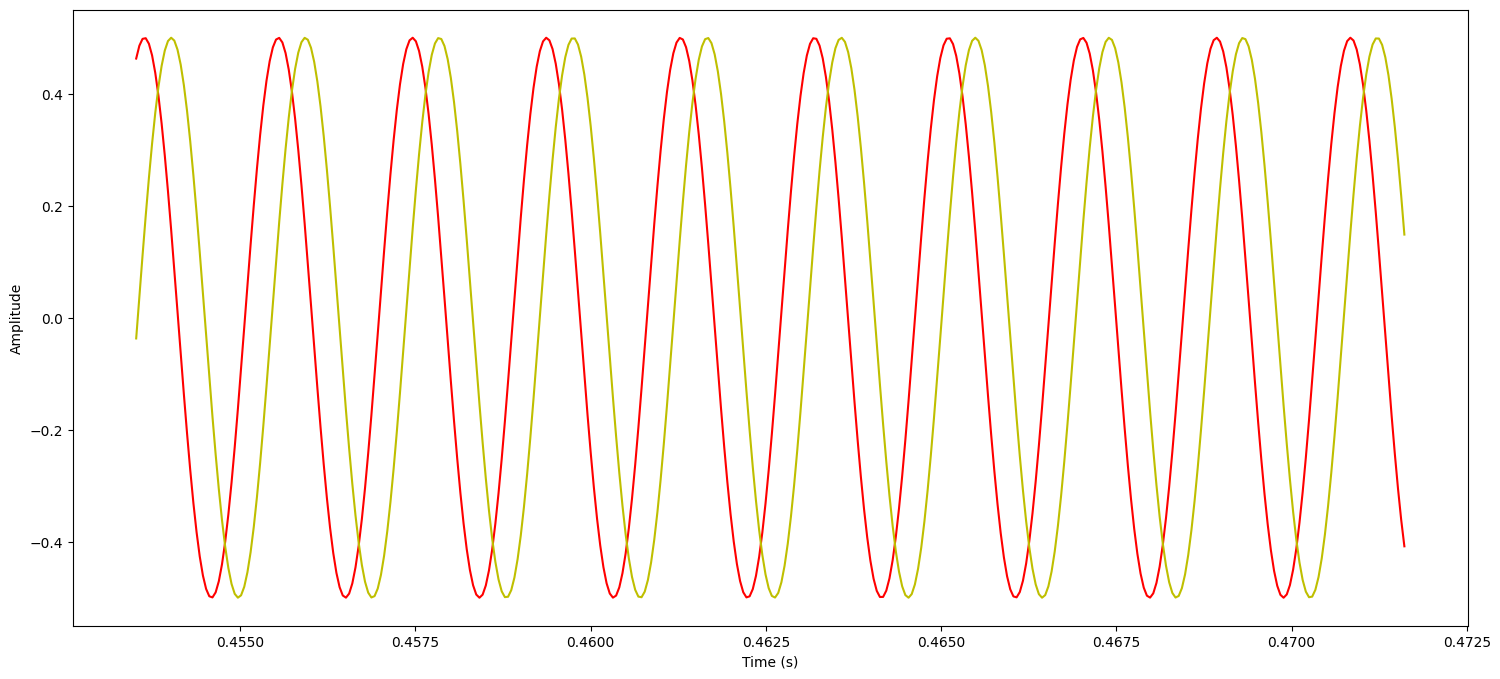

In [12]:
# create a sinusoid

f = 523
phase = 0
phase2 = 0.2

sin = 0.5 * np.sin(2*np.pi * (f * t - phase))
sin2 = 0.5 * np.sin(2*np.pi * (f * t - phase2))

plt.figure(figsize=(18, 8))
plt.plot(t[10000:10400], sin[10000:10400], color="r")
plt.plot(t[10000:10400], sin2[10000:10400], color="y")


plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

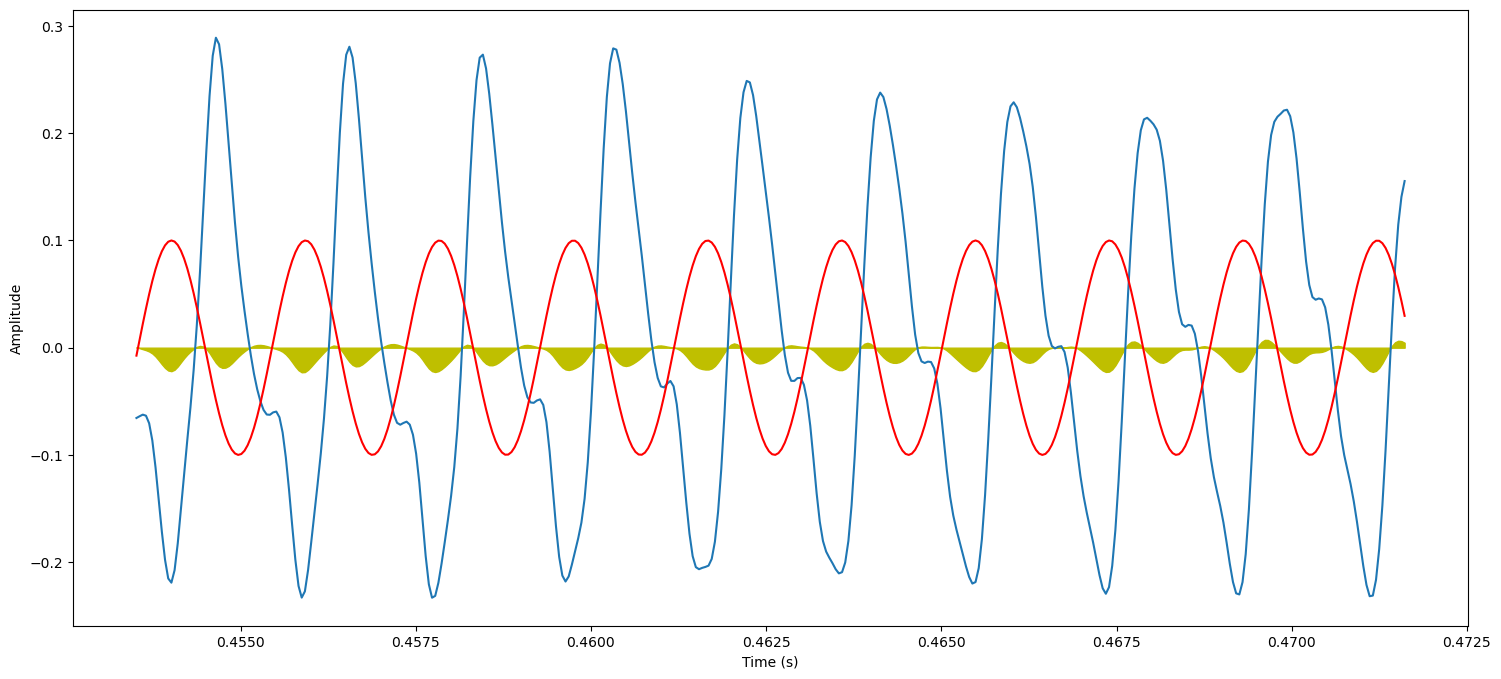

In [37]:
# compare signal and sinusoids

f = 523
phase = 0.2

sin = 0.1 * np.sin(2*np.pi * (f * t - phase))

plt.figure(figsize=(18, 8))
plt.plot(t[10000:10400], signal[10000:10400]) 
plt.plot(t[10000:10400], sin[10000:10400], color="r")

plt.fill_between(t[10000:10400], sin[10000:10400]*signal[10000:10400], color="y")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


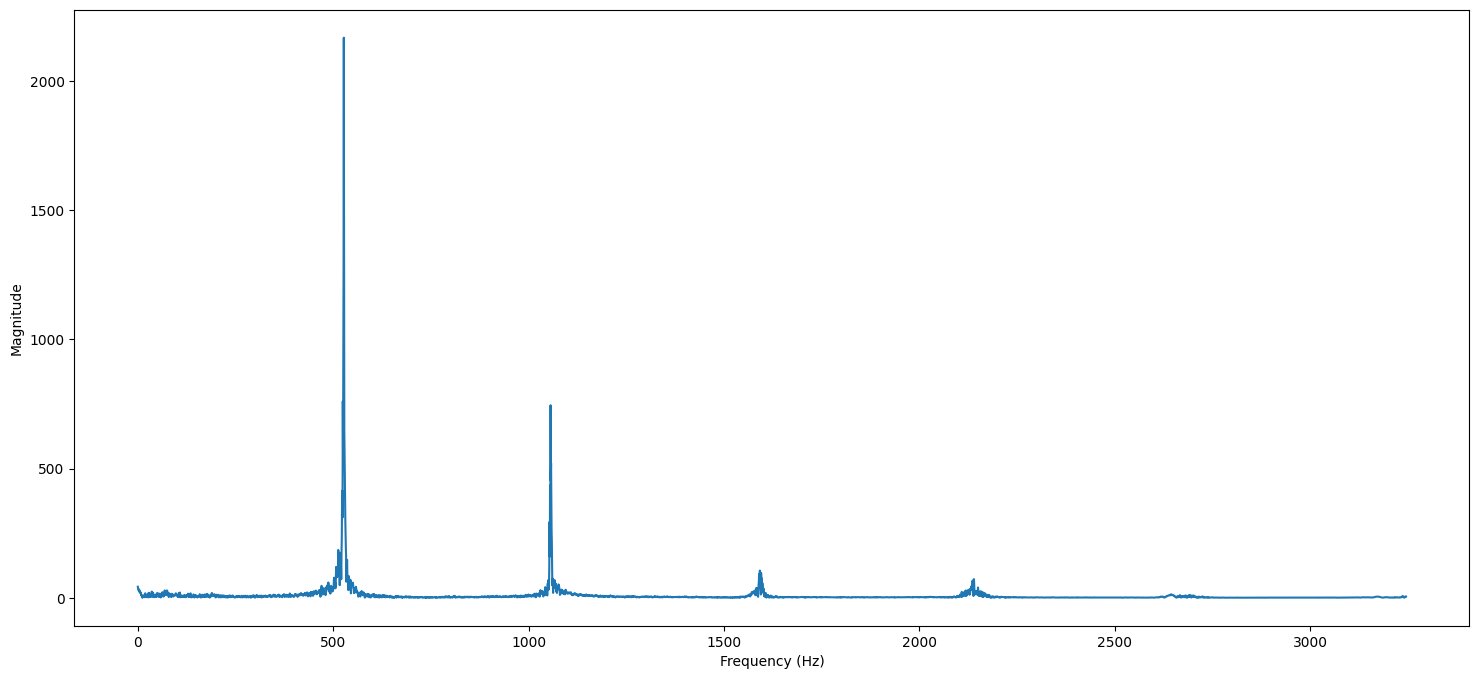

In [14]:
# plot spectrum
plt.figure(figsize=(18, 8))
plt.plot(frequency[:5000], magnitude[:5000]) # magnitude spectrum
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

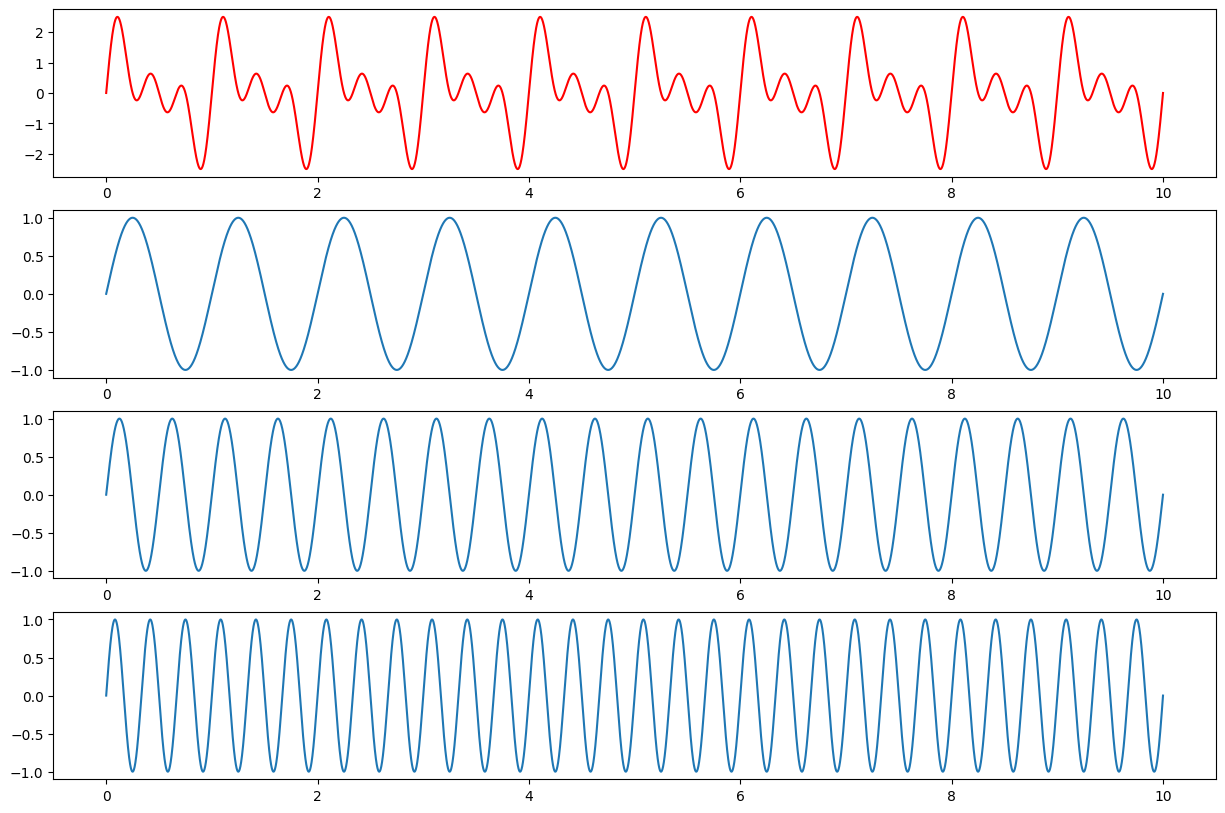

In [15]:
# superimposing pure tones
f = 1
t = np.linspace(0, 10, 10000)

sin = np.sin(2*np.pi * (f * t))
sin2 = np.sin(2*np.pi * (2*f * t))
sin3 = np.sin(2*np.pi * (3*f * t))

sum_signal = sin + sin2 + sin3

plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(t, sum_signal, color="r")

plt.subplot(4, 1, 2)
plt.plot(t, sin)

plt.subplot(4, 1, 3)
plt.plot(t, sin2)

plt.subplot(4, 1, 4)
plt.plot(t, sin3)

plt.show()

In [ ]:
Why create sinusoids?

Because Fourier Transform asks:

How much does this signal look like a sine/cosine wave of frequency f?

For every frequency, FFT compares the signal with a sinusoid.

For example:

compare signal with 100 Hz sine
compare signal with 200 Hz sine
compare signal with 523 Hz sine
compare signal with 1000 Hz sine
...

If the signal matches a frequency well, the multiplication mostly stays positive and the sum becomes large.

If the signal does not match, positive and negative areas cancel out and the sum becomes small.

That is the key idea.

Fourier Transform intuition

For one frequency:

score(f)=∑signal(t)×sinusoid
f
	​

(t)

If score is high:

that frequency is strongly present

If score is low:

that frequency is weak or absent

FFT does this for many frequencies very efficiently.

So your code is manually visualizing one tiny part of that idea for:

f = 523 Hz
What does phase do?
phase = 0.55

The phase shifts the sine wave left or right.

Why needed?

Because the audio may contain 523 Hz, but not starting from exactly the same point as your sine wave.

A sine wave can be shifted:

same frequency, different alignment

So phase helps check different alignments.

Small correction: in your formula,

np.sin(2*np.pi * (f * t - phase))

phase = 0.55 is being treated as cycles, not radians.

Because it becomes:

sin(2πft−2πphase)

If you wanted phase in radians, you would usually write:

sin = 0.1 * np.sin(2*np.pi*f*t - phase)
Simple summary

Your code does this:

1. Create a pure 523 Hz sine wave
2. Plot real audio waveform
3. Plot artificial 523 Hz sine wave on top
4. Multiply them point-by-point
5. Highlight the product area

Why?

Because this is the intuition behind Fourier Transform:

signal × sinusoid → tells how much that frequency exists in the signal

FFT does this for all frequency bins automatically.